In [1]:
import numpy as np
from network import *
from GNAR import *
from GNARID import *
import matplotlib.pyplot as plt
from tqdm import tqdm

## Simulation

In [396]:
# A
n8_14 = n8_14=Network(edges={0:[1,3,4],1:[0,6],2:[3,4],3:[2,4],4:[0,2],5:[0,1,4],6:[3],7:[4,6,2]},
                      dists ={0:np.array([5,3,5]),1:np.array([4,3]),2:np.array([5,3]),3:np.array([4,1]),4:np.array([3,4]),5:np.array([4,5,3]),6:np.array([3]),7:np.array([6,5,5])}, symmetry=True, gamma=3.)
gammas = []
coefses = []
progress_bar = tqdm(range(1000))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n8_14], 1, [1], [np.array([0.35,0.55])], False,True,[0.1*np.identity(8)], [1000], burn_in = 100) 
    g = GNARID(1,[1],intercept=False)
    g.fit(n8_14,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|███████████████████████████████████| 1000/1000 [06:06<00:00,  2.73it/s, coefs=[0.32985685 0.55823096], gamma=2.96]

3.007077077077077
0.213717663997549
[0.3498224  0.54945867]
[0.00904061 0.01131017]


In [395]:
# B
n8_14 = Network(edges={0:[1,3,4],1:[0,6],2:[3,4],3:[2,4],4:[0,2],5:[0,1,4],6:[3],7:[4,6,2]},
                      dists ={0:np.array([5,3,5]),1:np.array([4,3]),2:np.array([5,3]),3:np.array([4,1]),4:np.array([3,4]),5:np.array([4,5,3]),6:np.array([3]),7:np.array([6,5,5])}, symmetry=True, gamma=3.)
gammas = []
coefses = []
progress_bar = tqdm(range(1000))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n8_14], 2, [1,1], [np.array([0.35,0.25,0.15,-0.2])], False,True,[0.1*np.identity(8)], [1000], burn_in = 100) 
    g = GNARID(2,[1,1],intercept=False)
    g.fit(n8_14,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|█████████| 1000/1000 [07:38<00:00,  2.18it/s, coefs=[ 0.32887352  0.26133174  0.14413504 -0.20968601], gamma=2.64]

3.0535035035035034
0.530421067805413
[ 0.34993302  0.25002117  0.14979727 -0.20024293]
[0.01084382 0.01850595 0.01084197 0.01801457]


In [397]:
# C
n8_14 = n8_14=Network(edges={0:[1,3,4],1:[0,6],2:[3,4],3:[2,4],4:[0,2],5:[0,1,4],6:[3],7:[4,6,2]},
                      dists ={0:np.array([5,3,5]),1:np.array([4,3]),2:np.array([5,3]),3:np.array([4,1]),4:np.array([3,4]),5:np.array([4,5,3]),6:np.array([3]),7:np.array([6,5,5])}, symmetry=True, gamma=.6)
gammas = []
coefses = []
progress_bar = tqdm(range(1000))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n8_14], 2, [1,1], [np.array([0.35,0.25,0.15,-0.2])], False,True,[0.1*np.identity(8)], [1000], burn_in = 100) 
    g = GNARID(2,[1,1],intercept=False)
    g.fit(n8_14,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|█████████| 1000/1000 [09:08<00:00,  1.82it/s, coefs=[ 0.32845636  0.27571364  0.1438219  -0.21707738], gamma=0.38]

0.5876976976976976
0.21123290928401098
[ 0.34991733  0.24979322  0.1497218  -0.19956545]
[0.01088119 0.02056837 0.0109493  0.0205745 ]


## Misspecification

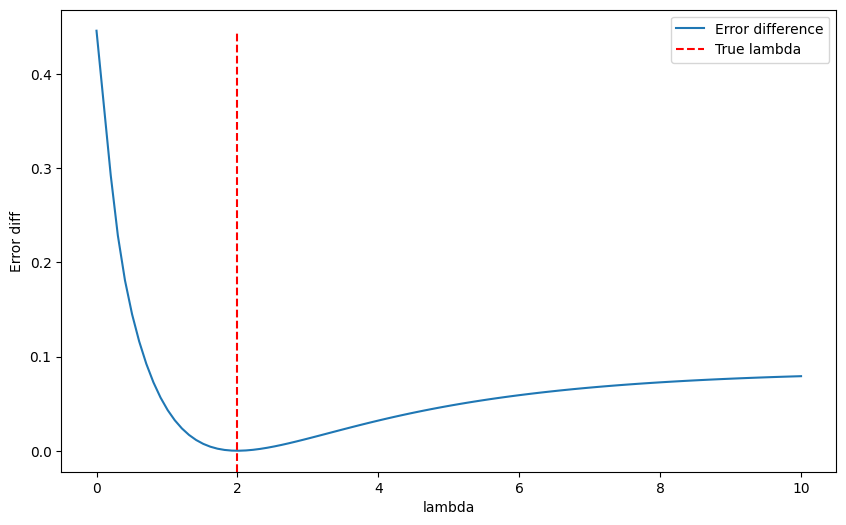

In [4]:
def random_network_dist(N):
    edges = {}
    dists = {}
    indices = [i for i in range(N)]
    for i in range(N):
        indices.remove(i)
        edges[i] = random.sample(indices,random.randint(int(N/4),int(N/4*3)))
        indices.append(i)
        dists[i] = np.random.exponential(size=len(edges[i]))
    return Network(edges,dists,symmetry=False)
np.random.seed(1)
random.seed(10)
n8_ran = random_network_dist(8)
gamma_true = 2.
n8_ran_true = deepcopy(n8_ran)
n8_ran_true.UpdateGamma(gamma_true)
diffs = []
for gamma in np.linspace(0,10,100):
    n8_ran_gamma = deepcopy(n8_ran)
    n8_ran_gamma.UpdateGamma(gamma)
    #autocovs = true_var_autocov([0.15*np.identity(8)+0.35*n8_ran_true.w_mats[1].T-0.45*n8_ran_true.w_mats[2].T],1*np.identity(8),10)
    #diff = gamma_pred_diff([1,1],np.array([0.35,-0.45]),n8_ran_true.w_mats,n8_ran_gamma.w_mats,autocovs)/8
    autocovs = true_var_autocov([0.15*np.identity(8)+0.75*n8_ran_true.w_mats[1].T],1*np.identity(8),10)
    diff = gamma_pred_diff([1],np.array([0.75]),n8_ran_true.w_mats,n8_ran_gamma.w_mats,autocovs)
    diffs.append(diff/8)
plt.figure(figsize=(10,6))
plt.plot(np.linspace(0,10,100),diffs,label="Error difference")
plt.axvline(2,0,0.95,color="red",linestyle="--",label="True lambda")
plt.xlabel("lambda")
plt.ylabel("Error diff")
plt.legend()
plt.show()

## Application

In [11]:
pix_vts = np.genfromtxt("Brumadinho\\max_brum_all_locs.ts_100pix.csv",delimiter=",")[1:,1:-4].T
locs = np.genfromtxt("Brumadinho\\max_brum_all_locs.ts_100pix.csv",delimiter=",")[1:,-4:-2]
for i in [86,89,90,96,98,99]:
    locs[i] += 0.1 #perturb some locs slightly to avoid zero distances
counts = np.genfromtxt("Brumadinho\\max_brum_all_locs.ts_100pix.csv",delimiter=",")[1:,-2]

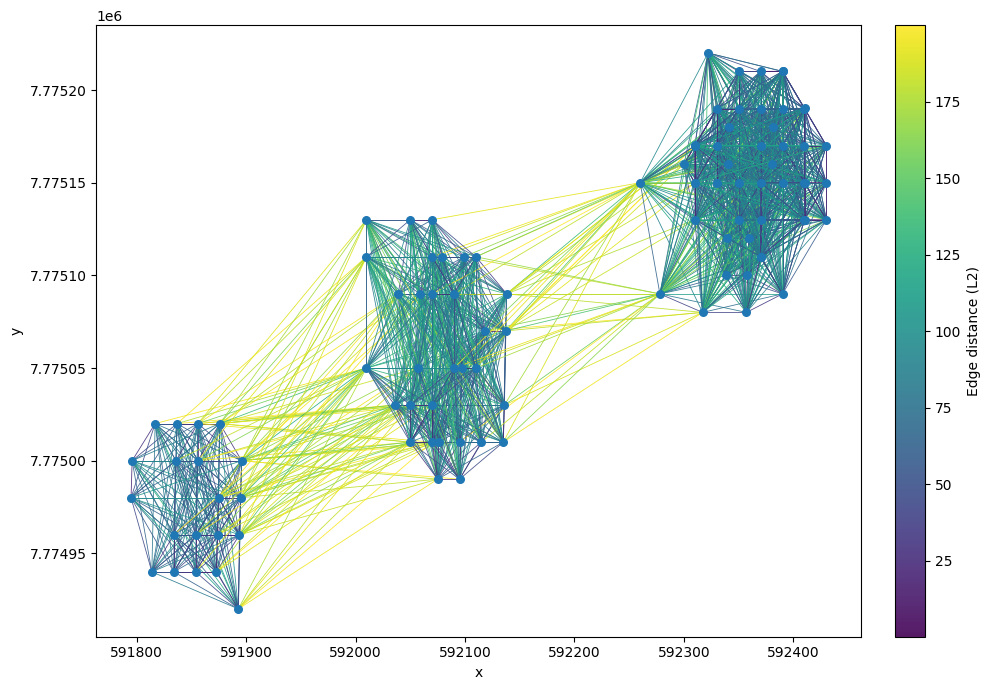

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def threshold_network_edges(loc, thresh=200.0):
    loc = np.asarray(loc, dtype=float)
    N = loc.shape[0]

    diffs = loc[:, None, :] - loc[None, :, :]
    D2 = np.sum(diffs**2, axis=2)
    mask = (D2 < thresh**2) & (~np.eye(N, dtype=bool))

    iu, ju = np.triu_indices(N, k=1)
    edges = [(i, j) for i, j in zip(iu, ju) if mask[i, j]]
    return edges

def plot_threshold_network_colored_by_dist(loc, edges, node_size=30, lw=0.6):
    loc = np.asarray(loc, dtype=float)
    fig, ax = plt.subplots(figsize=(10, 7))

    # build segments + distances
    segments = []
    dists = []
    for i, j in edges:
        p, q = loc[i], loc[j]
        segments.append([p, q])
        dists.append(np.linalg.norm(p - q))
    dists = np.asarray(dists)

    # edges as a LineCollection colored by distance
    if len(segments) > 0:
        norm = Normalize(vmin=dists.min(), vmax=dists.max())
        lc = LineCollection(segments, array=dists, linewidths=lw, norm=norm, alpha=0.9, cmap="viridis")
        ax.add_collection(lc)
        cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Edge distance (L2)")

    # nodes
    ax.scatter(loc[:, 0], loc[:, 1], s=node_size, zorder=3)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

edges = threshold_network_edges(locs, thresh=200.0)
plot_threshold_network_colored_by_dist(locs, edges)


In [ ]:
def get_edges_dists_dict_from_loc_count(locs,counts,norm=2,thresh=100,offset=1):
    N = len(locs)
    edges,dists= {},{}
    for i in range(N):
        edges[i] = []
        dists[i] = []
        for j in range(N):
            if i != j:
                dist = np.linalg.norm((locs[i]-locs[j]),ord=norm)
                if dist <= thresh:
                    edges[i].append(j)
                    dists[i].append(np.abs(counts[i]-counts[j])/15+offset)
        dists[i] = np.array(dists[i])
    return edges,dists
edges, dists = get_edges_dists_dict_from_loc_count(locs,counts,2,200,1)
dist_count_net_1 = Network(edges,dists,gamma=1.)
dist_count_net_0 = Network(edges,dists,gamma=0.)

In [14]:
p=2
b = 40
y = pix_vts

In [100]:
# AR
g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_0,y[:b])
print(g.validate(y[:b]))
print(g.validate(y[b-p:]))

0.060370631565497865
0.009839358957775886


In [102]:
# A
g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_0,y[:b])
print(g.validate(y[:b]))
print(g.validate(y[b-p:]))

0.054345375792940076
0.008071975262584713


In [101]:
# B
g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_1,y[:b])
print(g.validate(y[:b]))
print(g.validate(y[b-p:]))

0.05420759714068425
0.00801765898330629


9.0


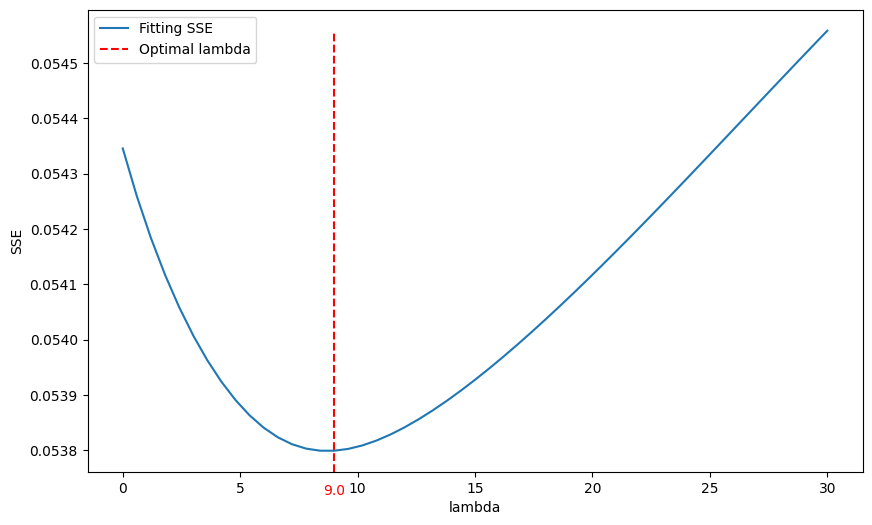

0.05379922834862759
0.007853216441116412


In [15]:
# C
g_bc = GNARID(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g_bc.fit(dist_count_net_1,y[:b],grid_search=True,search_start=0,search_end=30,search_num=51,use_ls=True,l2_penal=0.)
print(g_bc.gamma)
plt.figure(figsize=(10, 6))
plt.plot(g_bc.gammas,g_bc.losses,label="Fitting SSE")
plt.axvline(x=g_bc.gamma,ymin=0,ymax=0.95,color="red",linestyle='--',label="Optimal lambda")
plt.text(g_bc.gamma, -0.025, str(g_bc.gamma)[:3], color='red',
         ha='center', va='top', fontsize=10, transform=plt.gca().get_xaxis_transform())
#plt.title("Fitting SSE vs lambda")
plt.xlabel("lambda")
plt.ylabel("SSE")
plt.legend()
plt.show()
print(g_bc.validate(y[:b]))
print(g_bc.validate(y[b-p:]))